In [1]:
import numpy as np # linear algebra 
import pandas as pd # data processing 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [16]:
df = pd.read_csv('wine_data.csv' , header = None , usecols=[0,1,2])
df.columns = ['Class label' , 'Alcohol',' Malic Acid' ]

In [17]:
df

,Class label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

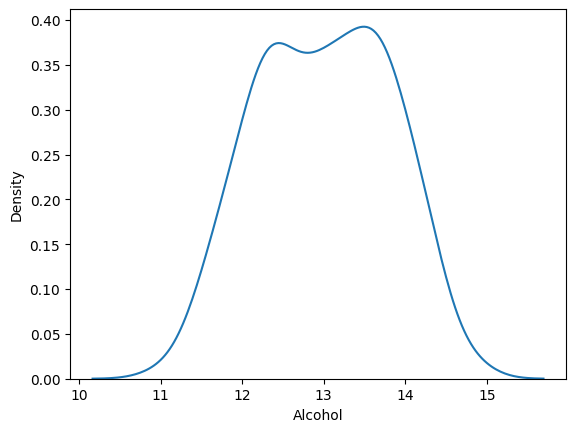

In [4]:
sns.kdeplot(df['Alcohol'] )

<Axes: xlabel=' Malic Acid', ylabel='Density'>

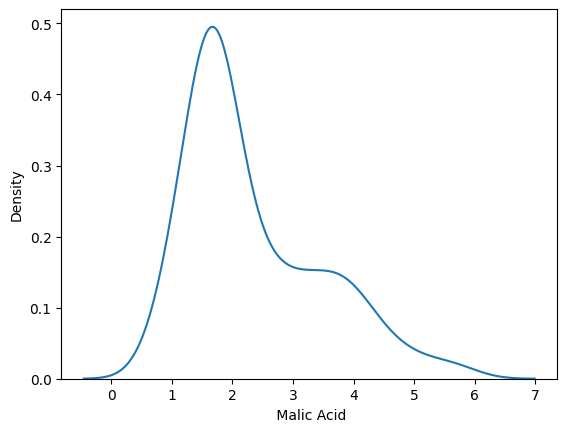

In [5]:
sns.kdeplot( df[' Malic Acid'])

<Axes: xlabel='Alcohol', ylabel=' Malic Acid'>

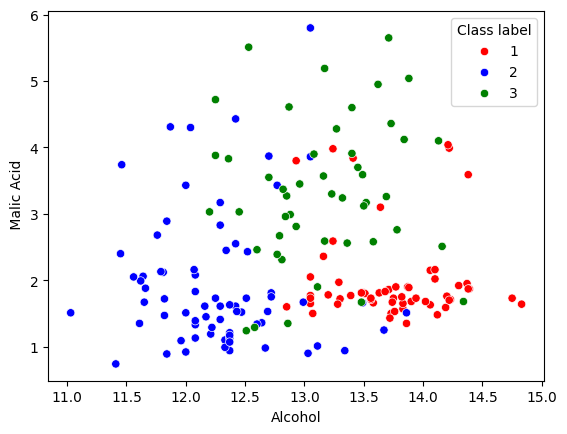

In [6]:
color_dict = {1:'red' , 3:'green', 2:'blue'}
sns.scatterplot(x = df['Alcohol'],y = df[' Malic Acid'],hue=df['Class label'], palette= color_dict)

In [7]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(df.drop('Class label' , axis = 1 ),
                                                       df['Class label'],
                                                       test_size = 0.3 , 
                                                       random_state = 0 )
X_train.shape , X_test.shape 

((124, 2), (54, 2))

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

#fir the  scalar to the train set , it will learn the parameters 
scaler.fit(X_train)

# transform train and test sets 
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)

In [10]:
np.round(X_train.describe() , 1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


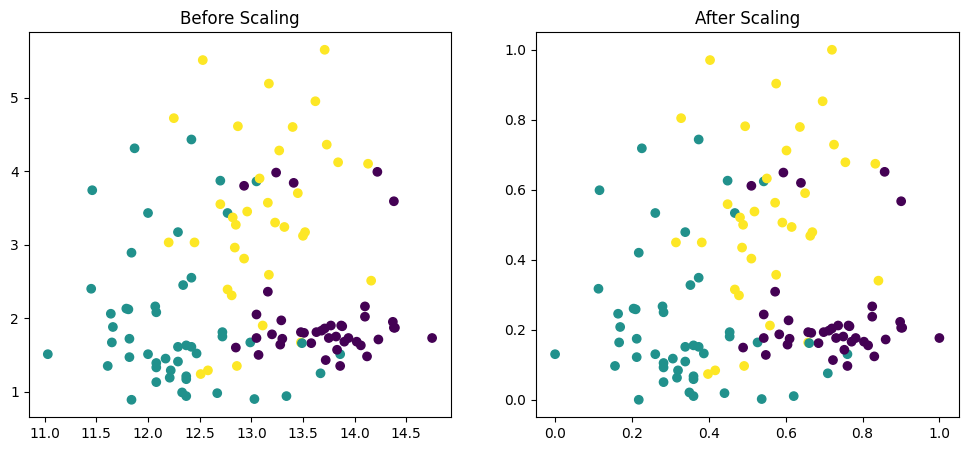

In [11]:
fig , (ax1 , ax2) = plt.subplots(ncols = 2  , figsize = (12, 5 ))

ax1.scatter(X_train['Alcohol'], X_train[' Malic Acid'] , c=y_train)
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled[' Malic Acid'] , c=y_train)
ax2.set_title('After Scaling')
plt.show()

In [12]:
df.columns


Index(['Class label', 'Alcohol', ' Malic Acid'], dtype='object')

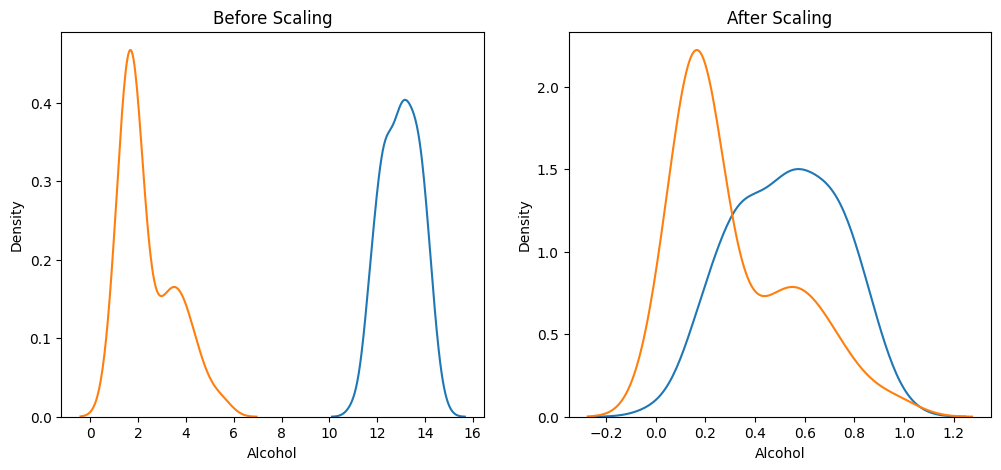

In [13]:
# convert scaled array to dataframe
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train[' Malic Acid'], ax=ax1)

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled_df['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled_df[' Malic Acid'], ax=ax2)

plt.show()
